# LangGraph Agent System: Retry Logic + Supervisor Architecture + Human-in-the-Loop

This notebook builds an end-to-end multi-agent workflow using **ChatGroq**.

It combines:

- Supervisor architecture
- Research worker
- Analysis worker
- Action worker
- LangGraph retry policy
- Human approval using `interrupt()`
- Checkpointing and resume using `Command`
- Conditional routing
- Safe stopping conditions

## Example task

> Research a product-launch situation, analyze it, prepare an executive email, and send it only after human approval.

```text
START
  ↓
Supervisor
  ├── Research worker
  ├── Analysis worker
  ├── Prepare action
  └── Finish
              ↓
        Human approval
        ├── Approve
        ├── Edit
        └── Reject
```


## Cell 1: Install Libraries

In [11]:
# %pip install -U langgraph langchain langchain-groq python-dotenv pydantic


## Cell 2: Import Libraries

In [12]:
import json
import os
from typing import Literal

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, RetryPolicy, interrupt


## Cell 3: Configure Groq API Key

Create a `.env` file:

```text
GROQ_API_KEY=your_groq_api_key
```


In [13]:
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY_S")

if not groq_api_key:
    raise ValueError(
        "GROQ_API_KEY was not found. Add it to your .env file."
    )


## Cell 4: Initialize ChatGroq

In [14]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=groq_api_key,
    max_retries=1,
    timeout=45,
)


## Cell 5: Supervisor Decision Schema

In [15]:
class SupervisorDecision(BaseModel):
    next_worker: Literal[
        "research",
        "analysis",
        "prepare_action",
        "finish",
    ] = Field(
        description="The next worker that should run."
    )

    reason: str = Field(
        description="A concise explanation for the routing decision."
    )


supervisor_llm = llm.with_structured_output(
    SupervisorDecision
)


## Cell 6: Shared Graph State

In [16]:
class AgentSystemState(TypedDict, total=False):
    user_request: str
    research_result: str
    analysis_result: str
    action_draft: dict
    action_status: str
    action_result: str
    supervisor_reason: str
    next_worker: str
    completed_workers: list[str]
    retry_demo_attempts: int
    final_answer: str


## Cell 7: Supervisor Prompt

In [17]:
SUPERVISOR_SYSTEM_PROMPT = """
You are the supervisor of a business workflow.

Available workers:

1. research
   Collects evidence and market information.

2. analysis
   Analyzes the research and produces recommendations.

3. prepare_action
   Creates a proposed executive email. This action
   requires human approval before execution.

4. finish
   Ends the workflow after the action is completed,
   rejected, or when no action is necessary.

Routing rules:

- Choose research when research_result is missing.
- Choose analysis when research_result exists but
  analysis_result is missing.
- Choose prepare_action when analysis_result exists
  but action_draft is missing.
- Choose finish when action_status is approved,
  edited, rejected, or executed.
- Never repeat a completed worker unless its output
  is missing.
"""


## Cell 8: Supervisor Node

In [18]:
def supervisor_node(
    state: AgentSystemState,
) -> dict:
    """Choose the next worker."""

    state_summary = {
        "user_request": state.get("user_request"),
        "has_research": bool(state.get("research_result")),
        "has_analysis": bool(state.get("analysis_result")),
        "has_action_draft": bool(state.get("action_draft")),
        "action_status": state.get("action_status", ""),
        "completed_workers": state.get("completed_workers", []),
    }

    decision = supervisor_llm.invoke(
        [
            SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    "Current workflow state:\n"
                    f"{json.dumps(state_summary, indent=2)}"
                )
            ),
        ]
    )

    return {
        "next_worker": decision.next_worker,
        "supervisor_reason": decision.reason,
    }


## Cell 9: Supervisor Router

In [19]:
def route_supervisor(
    state: AgentSystemState,
) -> Literal[
    "research",
    "analysis",
    "prepare_action",
    "finalize",
]:
    next_worker = state.get("next_worker", "finish")

    if next_worker == "research":
        return "research"

    if next_worker == "analysis":
        return "analysis"

    if next_worker == "prepare_action":
        return "prepare_action"

    return "finalize"


## Cell 10: Simulated External Research Service

In [20]:
research_attempt_counter = {"count": 0}


def fetch_market_data(topic: str) -> dict:
    """
    Simulate an unreliable external research service.

    The first call raises ConnectionError.
    The second call succeeds.
    """

    research_attempt_counter["count"] += 1

    if research_attempt_counter["count"] == 1:
        raise ConnectionError(
            "Temporary market-data service failure."
        )

    return {
        "topic": topic,
        "market_signals": [
            "Professionals prefer role-specific practice.",
            "Instant feedback is a strong differentiator.",
            "LinkedIn and YouTube are high-intent channels.",
            "Free trials can improve early activation.",
        ],
        "customer_pain_points": [
            "Interview content is fragmented.",
            "Candidates lack realistic mock interviews.",
            "Candidates receive limited feedback.",
        ],
        "recommended_channels": [
            "LinkedIn",
            "YouTube",
            "Technical communities",
            "Referral partnerships",
        ],
    }


## Cell 11: Research Worker

In [21]:
def research_worker_node(
    state: AgentSystemState,
) -> dict:
    market_data = fetch_market_data(
        state["user_request"]
    )

    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a research specialist. "
                    "Summarize the supplied evidence. "
                    "Do not invent additional facts."
                )
            ),
            HumanMessage(
                content=(
                    f"User request:\n{state['user_request']}\n\n"
                    f"Research data:\n"
                    f"{json.dumps(market_data, indent=2)}"
                )
            ),
        ]
    )

    completed = state.get("completed_workers", [])

    return {
        "research_result": response.content,
        "retry_demo_attempts": research_attempt_counter["count"],
        "completed_workers": [*completed, "research"],
    }


## Cell 12: Retry Policy

In [22]:
research_retry_policy = RetryPolicy(
    max_attempts=3,
    initial_interval=1.0,
    backoff_factor=2.0,
    max_interval=5.0,
    retry_on=ConnectionError,
)


## Cell 13: Analysis Worker

In [23]:
def analysis_worker_node(
    state: AgentSystemState,
) -> dict:
    response = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior business analyst. "
                    "Analyze the research, identify key "
                    "opportunities, risks, and practical next actions."
                )
            ),
            HumanMessage(
                content=(
                    f"Original request:\n{state['user_request']}\n\n"
                    f"Research result:\n{state['research_result']}"
                )
            ),
        ]
    )

    completed = state.get("completed_workers", [])

    return {
        "analysis_result": response.content,
        "completed_workers": [*completed, "analysis"],
    }


## Cell 14: Email Draft Schema

In [24]:
class EmailDraft(BaseModel):
    recipient: str
    subject: str
    body: str


email_draft_llm = llm.with_structured_output(
    EmailDraft
)


## Cell 15: Prepare Action Worker

In [25]:
def prepare_action_node(
    state: AgentSystemState,
) -> dict:
    draft = email_draft_llm.invoke(
        [
            SystemMessage(
                content=(
                    "Prepare a concise executive email based "
                    "only on the supplied analysis. "
                    "Use recipient 'leadership@example.com'."
                )
            ),
            HumanMessage(
                content=(
                    f"Original request:\n{state['user_request']}\n\n"
                    f"Analysis:\n{state['analysis_result']}"
                )
            ),
        ]
    )

    completed = state.get("completed_workers", [])

    return {
        "action_draft": draft.model_dump(),
        "action_status": "pending",
        "completed_workers": [*completed, "prepare_action"],
    }


## Cell 16: Human Approval Node

In [26]:
def human_approval_node(
    state: AgentSystemState,
) -> dict:
    """
    Pause execution and request a human decision.
    """

    review_request = {
        "message": "Review the proposed executive email.",
        "allowed_decisions": [
            "approve",
            "edit",
            "reject",
        ],
        "proposed_action": state["action_draft"],
    }

    human_response = interrupt(
        review_request
    )

    decision = human_response.get(
        "decision",
        "reject",
    )

    if decision == "approve":
        return {
            "action_status": "approved"
        }

    if decision == "edit":
        edited_action = human_response.get(
            "edited_action"
        )

        if not edited_action:
            return {
                "action_status": "rejected",
                "action_result": (
                    "Edit was selected, but no edited "
                    "action was provided."
                ),
            }

        return {
            "action_status": "edited",
            "action_draft": edited_action,
        }

    return {
        "action_status": "rejected",
        "action_result": (
            "Human rejected the action. "
            f"Reason: {human_response.get('reason', 'Not provided')}"
        ),
    }


## Cell 17: Route After Human Review

In [27]:
def route_after_approval(
    state: AgentSystemState,
) -> Literal[
    "execute_action",
    "finalize",
]:
    if state.get("action_status") in {
        "approved",
        "edited",
    }:
        return "execute_action"

    return "finalize"


## Cell 18: Simulated Email Execution

In [28]:
def send_email_simulation(
    recipient: str,
    subject: str,
    body: str,
) -> str:
    return (
        f"Email sent successfully to {recipient}. "
        f"Subject: {subject}"
    )


def execute_action_node(
    state: AgentSystemState,
) -> dict:
    action = state["action_draft"]

    result = send_email_simulation(
        recipient=action["recipient"],
        subject=action["subject"],
        body=action["body"],
    )

    return {
        "action_status": "executed",
        "action_result": result,
    }


## Cell 19: Finalization Node

In [29]:
def finalize_node(
    state: AgentSystemState,
) -> dict:
    status = state.get(
        "action_status",
        "not_required",
    )

    if status == "executed":
        final_answer = (
            "Workflow completed successfully.\n\n"
            f"Research:\n{state.get('research_result', '')}\n\n"
            f"Analysis:\n{state.get('analysis_result', '')}\n\n"
            f"Action result:\n{state.get('action_result', '')}"
        )

    elif status == "rejected":
        final_answer = (
            "Workflow stopped after human review.\n\n"
            f"Reason:\n{state.get('action_result', '')}"
        )

    else:
        final_answer = (
            "Workflow completed without executing "
            "a sensitive action."
        )

    return {
        "final_answer": final_answer
    }


## Cell 20: Build the Graph

In [30]:
builder = StateGraph(
    AgentSystemState
)

builder.add_node(
    "supervisor",
    supervisor_node,
)

builder.add_node(
    "research",
    research_worker_node,
    retry_policy=research_retry_policy,
)

builder.add_node(
    "analysis",
    analysis_worker_node,
)

builder.add_node(
    "prepare_action",
    prepare_action_node,
)

builder.add_node(
    "human_approval",
    human_approval_node,
)

builder.add_node(
    "execute_action",
    execute_action_node,
)

builder.add_node(
    "finalize",
    finalize_node,
)

builder.add_edge(
    START,
    "supervisor",
)

builder.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {
        "research": "research",
        "analysis": "analysis",
        "prepare_action": "prepare_action",
        "finalize": "finalize",
    },
)

builder.add_edge(
    "research",
    "supervisor",
)

builder.add_edge(
    "analysis",
    "supervisor",
)

builder.add_edge(
    "prepare_action",
    "human_approval",
)

builder.add_conditional_edges(
    "human_approval",
    route_after_approval,
    {
        "execute_action": "execute_action",
        "finalize": "finalize",
    },
)

builder.add_edge(
    "execute_action",
    "finalize",
)

builder.add_edge(
    "finalize",
    END,
)


## Cell 21: Compile with Checkpointer

In [31]:
checkpointer = InMemorySaver()

agent_system = builder.compile(
    checkpointer=checkpointer
)


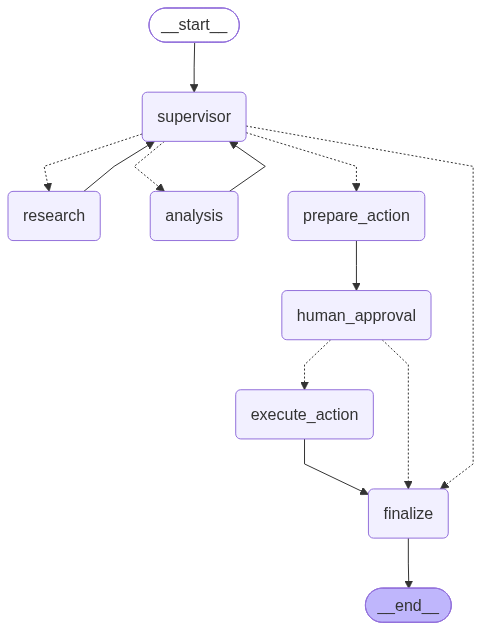

In [32]:
# ==========================================================
# Cell 6 : Visualize the LangGraph Workflow
# ==========================================================

from IPython.display import Image, display

# Display the graph
display(
    Image(
        agent_system.get_graph().draw_mermaid_png()
    )
)

## Cell 22: Define Task and Thread

In [ ]:
user_request = """
Research the launch opportunity for an AI-powered
interview-preparation product in India.

Analyze the strongest market opportunities and risks.

Then prepare a concise executive email for leadership.
Do not send the email without human approval.
"""


config = {
    "configurable": {
        "thread_id": "supervisor-hitl-demo-001"
    },
    "recursion_limit": 25,
}


## Cell 23: Start Workflow Until Interrupt

In [ ]:
initial_result = agent_system.invoke(
    {
        "user_request": user_request,
        "completed_workers": [],
    },
    config=config,
)

print(initial_result)


## Cell 24: Inspect Interrupt

In [ ]:
interrupts = initial_result.get(
    "__interrupt__",
    [],
)

if interrupts:
    print("Workflow paused for approval.")

    for current_interrupt in interrupts:
        print(
            json.dumps(
                current_interrupt.value,
                indent=2,
                default=str,
            )
        )
else:
    print(
        "No interrupt was found. Inspect initial_result."
    )


## Cell 25: Approve and Resume

In [ ]:
approved_result = agent_system.invoke(
    Command(
        resume={
            "decision": "approve"
        }
    ),
    config=config,
)

print(approved_result["final_answer"])


## Cell 26: Edit and Resume

Use a fresh thread ID before testing this path.


In [ ]:
edited_action = {
    "recipient": "product-leadership@example.com",
    "subject": "Edited: AI Interview Product Launch Recommendation",
    "body": (
        "Leadership team,\n\n"
        "The research indicates a strong opportunity for "
        "role-specific AI interview preparation. "
        "I recommend validating demand through a focused "
        "pilot before scaling acquisition.\n\n"
        "Regards"
    ),
}


edited_result = agent_system.invoke(
    Command(
        resume={
            "decision": "edit",
            "edited_action": edited_action,
        }
    ),
    config=config,
)

print(edited_result["final_answer"])


## Cell 27: Reject and Resume

Use another fresh thread ID before testing this path.


In [ ]:
rejected_result = agent_system.invoke(
    Command(
        resume={
            "decision": "reject",
            "reason": (
                "The analysis needs finance-team review "
                "before leadership communication."
            ),
        }
    ),
    config=config,
)

print(rejected_result["final_answer"])


## Cell 28: Interactive Runner

In [ ]:
def run_interactive_workflow(
    request: str,
    thread_id: str,
):
    workflow_config = {
        "configurable": {
            "thread_id": thread_id
        },
        "recursion_limit": 25,
    }

    result = agent_system.invoke(
        {
            "user_request": request,
            "completed_workers": [],
        },
        config=workflow_config,
    )

    interrupts = result.get(
        "__interrupt__",
        [],
    )

    if not interrupts:
        return result

    review_data = interrupts[0].value

    print("\nProposed action:")
    print(
        json.dumps(
            review_data["proposed_action"],
            indent=2,
        )
    )

    decision = input(
        "\nChoose approve, edit, or reject: "
    ).strip().lower()

    if decision == "approve":
        resume_value = {
            "decision": "approve"
        }

    elif decision == "edit":
        original_action = review_data[
            "proposed_action"
        ]

        edited_subject = input(
            "Enter edited subject: "
        ).strip()

        edited_body = input(
            "Enter edited body: "
        ).strip()

        resume_value = {
            "decision": "edit",
            "edited_action": {
                "recipient": original_action[
                    "recipient"
                ],
                "subject": (
                    edited_subject
                    or original_action["subject"]
                ),
                "body": (
                    edited_body
                    or original_action["body"]
                ),
            },
        }

    else:
        rejection_reason = input(
            "Enter rejection reason: "
        ).strip()

        resume_value = {
            "decision": "reject",
            "reason": (
                rejection_reason
                or "Rejected by reviewer."
            ),
        }

    return agent_system.invoke(
        Command(
            resume=resume_value
        ),
        config=workflow_config,
    )


## Cell 29: Run Interactive Example

In [ ]:
interactive_result = run_interactive_workflow(
    request=user_request,
    thread_id="interactive-supervisor-demo-001",
)

print("\nFinal answer:")
print(interactive_result["final_answer"])


## Cell 30: Inspect Retry Count

In [ ]:
print(
    "Research attempts:",
    interactive_result.get(
        "retry_demo_attempts"
    ),
)


## Cell 31: Stream Updates Until Approval

In [ ]:
stream_config = {
    "configurable": {
        "thread_id": "stream-supervisor-demo-001"
    },
    "recursion_limit": 25,
}


for event in agent_system.stream(
    {
        "user_request": user_request,
        "completed_workers": [],
    },
    config=stream_config,
    stream_mode="updates",
):
    print(
        json.dumps(
            event,
            indent=2,
            default=str,
        )
    )
    print("-" * 100)


# Step-by-Step Logic

1. The user provides a business request.
2. The supervisor routes to the research worker.
3. The research service fails on its first call.
4. `RetryPolicy` retries the research node.
5. Research succeeds and state is updated.
6. The supervisor routes to analysis.
7. The analysis worker creates recommendations.
8. The supervisor routes to action preparation.
9. The action worker creates an email draft.
10. `interrupt()` pauses the graph.
11. `InMemorySaver` preserves state.
12. The human approves, edits, or rejects.
13. The graph resumes with `Command(resume=...)`.
14. Approved or edited actions execute.
15. Rejected actions stop safely.
16. The final node creates the workflow result.

## Production Notes

- Use a persistent database checkpointer in production.
- Retry only transient failures such as network errors.
- Do not automatically retry validation or permission failures.
- Sensitive actions should be idempotent.
- Add authentication, authorization, and audit logs.
- Do not rely only on prompts for security.
